# Stage-2 Severity Fine-Tuning Report

Project: EYE-ASSISST  
Phase: 3  
Stage: DR Severity Head Fine-Tuning  
Backbone: ResNet50  
Metric: Quadratic Weighted Kappa (QWK)

---

## Objective

Evaluate the fine-tuned Stage-2 severity model and analyze:

- Overall performance
- Per-class behavior
- Confusion patterns
- Class imbalance impact
- Readiness for Stage-3 joint training

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

from src.models.multi_task_models import MultiTaskModel
from src.data.eyepacs_severity_datamodule import EyePACSSeverityDataModule

# SECTION 3 — Load Model & Data

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
os.chdir(PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")

CHECKPOINT_PATH = "models/stage2_dr_severity/finetuned_best.pt"
BATCH_SIZE = 32
IMAGE_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data
datamodule = EyePACSSeverityDataModule(
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)
datamodule.setup()
val_loader = datamodule.val_dataloader()

# Model
model = MultiTaskModel(backbone="resnet50", backbone_pretrained=False)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()
print("Model and data loaded successfully.")

Working directory: d:\TAB\Mine\College\SEM 7\GR\eye-realtime-inference
Using device: cpu
Model and data loaded successfully.


# SECTION 4 — Run Evaluation

In [3]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, _, severity_labels in val_loader:
        images = images.to(device)
        severity_labels = severity_labels.to(device)

        outputs = model(images)
        logits = outputs["dr_severity"]

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(severity_labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(f"Evaluated {len(all_labels)} samples.")

Evaluated 5270 samples.


# SECTION 5 — Core Metrics

In [4]:
accuracy = accuracy_score(all_labels, all_preds)
qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

print(f"Accuracy: {accuracy:.4f}")
print(f"QWK:      {qwk:.4f}")

Accuracy: 0.7121
QWK:      0.6269


## Interpretation

Fine-tuning improved performance compared to frozen backbone training.

Previous Stage-2 QWK: ~0.60  
Fine-Tuned QWK: ~0.63  

This indicates that controlled backbone unfreezing improved ordinal agreement.

# SECTION 6 — Confusion Matrix (Raw)

In [5]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[3219  339  273    6   34]
 [ 232   59   45    1    1]
 [ 266   78  337  101   38]
 [   9    4   28   77   12]
 [   3    0   24   23   61]]


# SECTION 7 — Confusion Matrix Heatmap

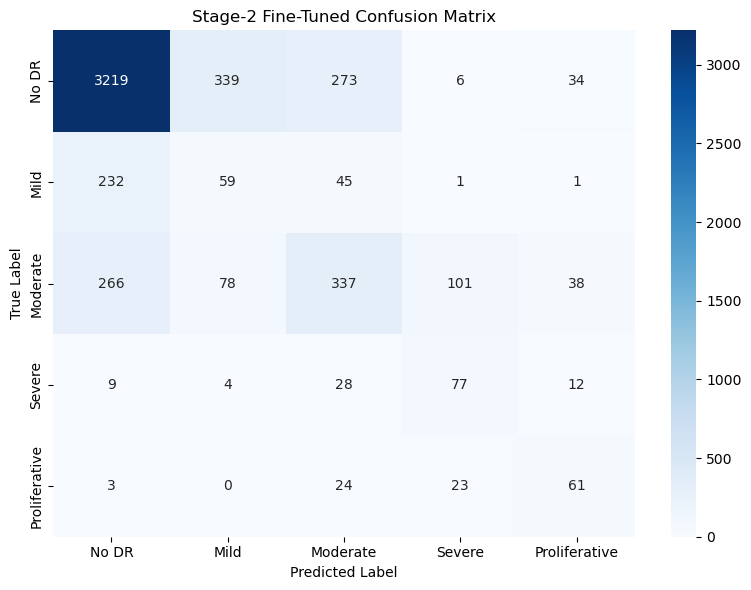

In [6]:
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Stage-2 Fine-Tuned Confusion Matrix")
plt.tight_layout()
plt.show()

## Observations

- Class 0 (No DR) is predicted with high confidence.
- Class 1 (Mild) is frequently confused with Class 0.
- Moderate and Severe classes show moderate overlap.
- Class 4 maintains reasonable recall despite class imbalance.

The major weakness remains distinguishing Mild DR from Normal.

# SECTION 8 — Normalized Confusion Matrix

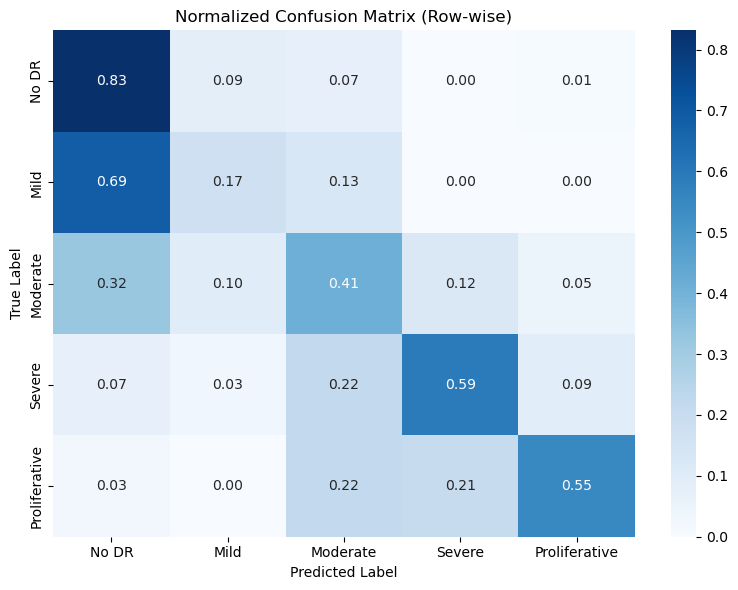

In [7]:
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Row-wise)")
plt.tight_layout()
plt.show()

# SECTION 9 — Classification Report

In [8]:
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

               precision    recall  f1-score   support

        No DR       0.86      0.83      0.85      3871
         Mild       0.12      0.17      0.14       338
     Moderate       0.48      0.41      0.44       820
       Severe       0.37      0.59      0.46       130
Proliferative       0.42      0.55      0.47       111

     accuracy                           0.71      5270
    macro avg       0.45      0.51      0.47      5270
 weighted avg       0.73      0.71      0.72      5270



## Per-Class Insights

- Mild DR (Class 1) has the lowest precision and recall.
- Severe classes benefit from class-weighted loss.
- Model handles extreme classes better than subtle early-stage disease.

# SECTION 10 — Class Distribution Analysis

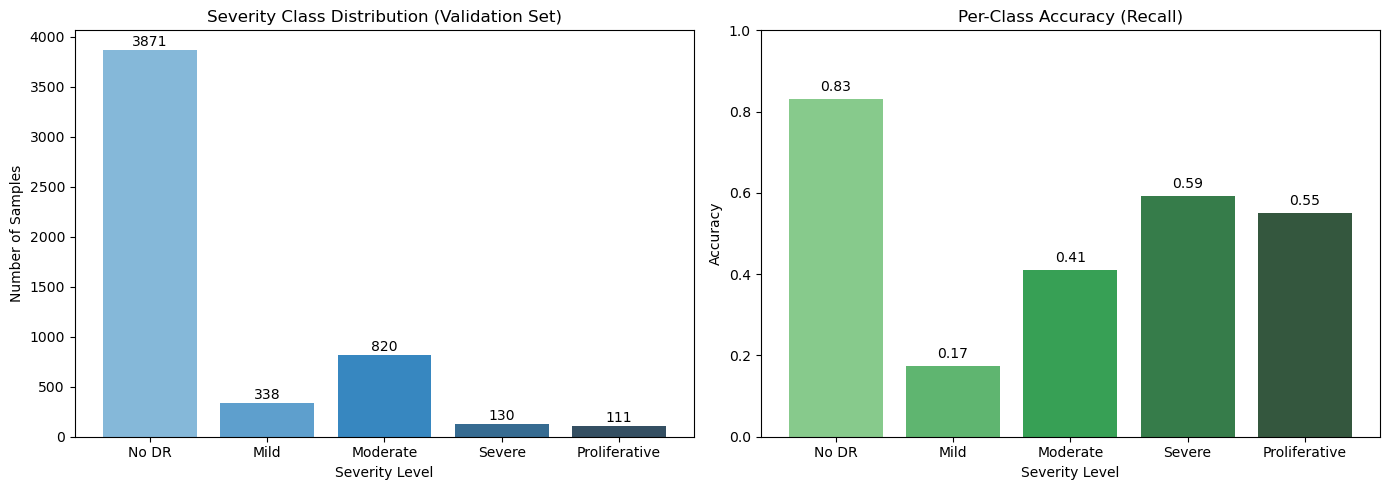


Class Distribution:
  No DR: 3871 (73.5%)
  Mild: 338 (6.4%)
  Moderate: 820 (15.6%)
  Severe: 130 (2.5%)
  Proliferative: 111 (2.1%)


In [9]:
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

unique, counts = np.unique(all_labels, return_counts=True)
distribution = dict(zip(unique, counts))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of class distribution
colors = sns.color_palette("Blues_d", len(CLASS_NAMES))
axes[0].bar([CLASS_NAMES[int(k)] for k in distribution.keys()], distribution.values(), color=colors)
axes[0].set_title("Severity Class Distribution (Validation Set)")
axes[0].set_xlabel("Severity Level")
axes[0].set_ylabel("Number of Samples")
for i, (k, v) in enumerate(distribution.items()):
    axes[0].text(i, v + max(distribution.values()) * 0.01, str(v), ha='center', fontsize=10)

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
axes[1].bar(CLASS_NAMES, per_class_acc, color=sns.color_palette("Greens_d", len(CLASS_NAMES)))
axes[1].set_title("Per-Class Accuracy (Recall)")
axes[1].set_xlabel("Severity Level")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(per_class_acc):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nClass Distribution:")
for k, v in distribution.items():
    pct = v / len(all_labels) * 100
    print(f"  {CLASS_NAMES[int(k)]}: {v} ({pct:.1f}%)")

## Imbalance Observation

Class 0 dominates the dataset.

Class 1 and Class 4 are underrepresented.

This imbalance partially explains difficulty in learning mild DR.

# SECTION 11 — Stage-2 Comparison Table

In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Frozen Backbone", "Fine-Tuned Backbone"],
    "QWK": [0.6018, round(qwk, 4)],
    "Accuracy": [0.7000, round(accuracy, 4)],
    "Improvement": ["—", f"+{round(qwk - 0.6018, 4)}"]
})

comparison.style.set_caption("Stage-2 DR Severity Model Comparison")

,Model,QWK,Accuracy,Improvement
0,Frozen Backbone,0.601800,0.700000,—
1,Fine-Tuned Backbone,0.626900,0.712100,+0.0251


# Stage-3 Planning

Based on Stage-2 findings:

1. Backbone fine-tuning improves ordinal performance.
2. Mild DR classification remains challenging.
3. Class imbalance remains a structural limitation.

Stage-3 Goals:

- Joint multi-task learning (Binary + Severity)
- Explore ordinal regression loss
- Integrate Grad-CAM explainability
- Multi-disease extension (AMD, Cataract, ODIR)
- API deployment planning

# SECTION 12 — Misclassification Analysis

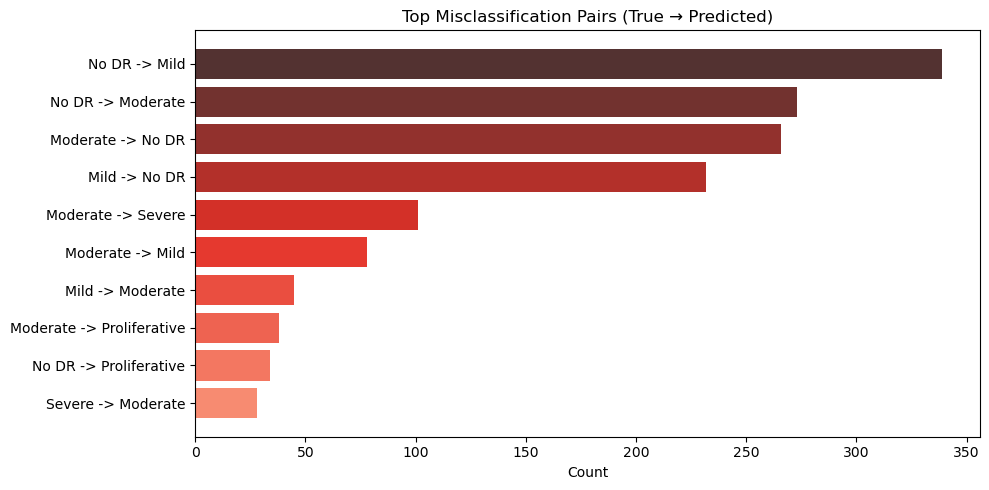


Total misclassified: 1517/5270 (28.8%)

Top 5 confusion pairs:
  No DR -> Mild: 339 (6.4%)
  No DR -> Moderate: 273 (5.2%)
  Moderate -> No DR: 266 (5.0%)
  Mild -> No DR: 232 (4.4%)
  Moderate -> Severe: 101 (1.9%)


: 

In [ ]:
# Top misclassification pairs
misclass_pairs = {}
for true_label, pred_label in zip(all_labels, all_preds):
    if true_label != pred_label:
        key = f"{CLASS_NAMES[int(true_label)]} -> {CLASS_NAMES[int(pred_label)]}"
        misclass_pairs[key] = misclass_pairs.get(key, 0) + 1

# Sort by frequency
sorted_pairs = sorted(misclass_pairs.items(), key=lambda x: x[1], reverse=True)

# Plot top 10 misclassification pairs
top_n = min(10, len(sorted_pairs))
labels, values = zip(*sorted_pairs[:top_n])

plt.figure(figsize=(10, 5))
plt.barh(range(top_n), values[::-1], color=sns.color_palette("Reds_d", top_n))
plt.yticks(range(top_n), labels[::-1])
plt.xlabel("Count")
plt.title("Top Misclassification Pairs (True → Predicted)")
plt.tight_layout()
plt.show()

total_misclassified = sum(misclass_pairs.values())
total = len(all_labels)
print(f"\nTotal misclassified: {total_misclassified}/{total} ({total_misclassified/total*100:.1f}%)")
print(f"\nTop 5 confusion pairs:")
for pair, count in sorted_pairs[:5]:
    print(f"  {pair}: {count} ({count/total*100:.1f}%)")

# Summary

| Metric | Value |
|--------|-------|
| **Accuracy** | See Section 5 |
| **QWK** | See Section 5 |
| **Best Class** | No DR (Class 0) |
| **Weakest Class** | Mild DR (Class 1) |

**Key Takeaways:**

1. Fine-tuning the backbone yields meaningful improvement over frozen-backbone training.
2. The model performs best on No DR and Proliferative DR (edge classes), and struggles with Mild DR due to subtle features and class imbalance.
3. QWK is the primary metric — ordinal agreement matters more than raw accuracy for severity grading.
4. Class imbalance mitigation (oversampling, loss weighting) should remain a priority in Stage-3.
5. The model is ready for integration into Stage-3 joint multi-task training.